# Cell 1 - imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cell 2 — Paths and output folders

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

SUMMARIES_DIR = PROJECT_ROOT / "reports" / "summaries"
VIS_DIR = PROJECT_ROOT / "reports" / "visualizations" / "project_distributions"
PNG_DIR = VIS_DIR / "png"
SVG_DIR = VIS_DIR / "svg"

VIS_DIR.mkdir(parents=True, exist_ok=True)
PNG_DIR.mkdir(parents=True, exist_ok=True)
SVG_DIR.mkdir(parents=True, exist_ok=True)

long_usable_path = SUMMARIES_DIR / "cycle_time_long_issue_level_usable_only.csv"

print("Reading:", long_usable_path)
print("Saving figures to:", VIS_DIR)

Reading: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/summaries/cycle_time_long_issue_level_usable_only.csv
Saving figures to: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions


# Cell 3 — Load data

In [3]:
df = pd.read_csv(long_usable_path)

print(df.shape)
display(df.head())
print(df.columns.tolist())

(92304, 18)


/var/folders/hy/9mxkxprj2dlb6w9_fhfd2zzh0000gn/T/ipykernel_64691/2390627087.py:1: DtypeWarning: Columns (0: Sprint_Name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(long_usable_path)


,Project_Key,Issue_ID,Issue_Key,Issue_Type,Priority,Sprint_ID,Sprint_Name,Story_Point,Created,Resolution,First_In_Progress_Timestamp,First_Done_Timestamp,Final_Done_Timestamp,Was_Reopened,CT_Definition,CT_Column,Cycle_Time_Minutes,Usable
0,SERVER,479182,SERVER-32497,Bug,Major - P3,NaN,NaN,NaN,2018-01-01 01:16:56,2018-01-02 17:37:10,NaN,2018-01-02 17:37:10,2018-01-29 17:29:44,0,CT1,CT1_Resolution_Time_Minutes,2420.0,True
1,SERVER,479181,SERVER-32498,Bug,Major - P3,NaN,NaN,NaN,2018-01-01 02:20:46,2018-02-05 16:25:16,2018-01-17 19:47:07,2018-02-05 16:25:16,2018-02-05 16:25:16,0,CT1,CT1_Resolution_Time_Minutes,51244.0,True
2,SERVER,479180,SERVER-32499,Bug,Major - P3,NaN,NaN,NaN,2018-01-01 08:57:08,2018-01-03 04:25:52,NaN,2018-01-03 04:25:52,2018-01-03 04:25:52,0,CT1,CT1_Resolution_Time_Minutes,2608.0,True
3,SERVER,479179,SERVER-32500,Task,Major - P3,NaN,NaN,NaN,2018-01-01 17:23:11,2018-01-01 18:32:41,NaN,2018-01-01 18:32:41,2018-01-29 17:30:19,0,CT1,CT1_Resolution_Time_Minutes,69.0,True
4,SERVER,479178,SERVER-32501,Improvement,Major - P3,NaN,NaN,NaN,2018-01-02 05:27:53,2018-01-15 05:23:57,2018-01-05 00:12:28,2018-01-15 05:23:57,2018-01-15 05:23:57,0,CT1,CT1_Resolution_Time_Minutes,18716.0,True


['Project_Key', 'Issue_ID', 'Issue_Key', 'Issue_Type', 'Priority', 'Sprint_ID', 'Sprint_Name', 'Story_Point', 'Created', 'Resolution', 'First_In_Progress_Timestamp', 'First_Done_Timestamp', 'Final_Done_Timestamp', 'Was_Reopened', 'CT_Definition', 'CT_Column', 'Cycle_Time_Minutes', 'Usable']


# Cell 4 — Clean and prepare data

In [4]:
df.columns = [c.strip() for c in df.columns]

required_cols = {
    "Project_Key",
    "Issue_ID",
    "Issue_Key",
    "CT_Definition",
    "Cycle_Time_Minutes"
}
missing = required_cols - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

df["Project_Key"] = df["Project_Key"].astype(str)
df["CT_Definition"] = df["CT_Definition"].astype(str)
df["Cycle_Time_Minutes"] = pd.to_numeric(df["Cycle_Time_Minutes"], errors="coerce")
df = df.dropna(subset=["Cycle_Time_Minutes"]).copy()
df = df[df["Cycle_Time_Minutes"] > 0].copy()

df["Cycle_Time_Days"] = df["Cycle_Time_Minutes"] / 1440.0

project_order = ["SERVER", "MDL", "JRACLOUD"]

def ct_sort_key(ct):
    digits = "".join(ch for ch in str(ct) if ch.isdigit())
    return int(digits) if digits else 999

ct_order = sorted(df["CT_Definition"].dropna().unique().tolist(), key=ct_sort_key)

print("Projects:", sorted(df["Project_Key"].unique().tolist()))
print("CT definitions:", ct_order)
print("Rows after filtering:", len(df))

Projects: ['JRACLOUD', 'MDL', 'SERVER']
CT definitions: ['CT1', 'CT2', 'CT3', 'CT4', 'CT5', 'CT6']
Rows after filtering: 92304


# Cell 5 - save helper

In [5]:
def save_figure(fig, name, dpi=200):
    png_path = PNG_DIR / f"{name}.png"
    svg_path = SVG_DIR / f"{name}.svg"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", svg_path)

# Cell 6 - overview counts

In [6]:
counts = (
    df.groupby(["Project_Key", "CT_Definition"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=project_order, columns=ct_order)
)

display(counts)

CT_Definition,CT1,CT2,CT3,CT4,CT5,CT6
Project_Key,,,,,,
SERVER,15963,8645,15963,9146,9169,9101
MDL,4896,0,4896,3463,3463,3447
JRACLOUD,1644,218,1644,243,265,138


Cell 7 — Choose a main CT definition for project-level distributions

In [7]:
# Use one CT definition at a time for project-level distributions,
# otherwise the same issue can appear multiple times across CT definitions.
MAIN_CT = "CT1"

main_df = df[df["CT_Definition"] == MAIN_CT].copy()

print("Rows for", MAIN_CT, ":", len(main_df))
display(
    main_df.groupby("Project_Key")["Cycle_Time_Days"]
    .agg(["count", "median", "mean", "min", "max"])
    .reindex(project_order)
)

Rows for CT1 : 22503


,count,median,mean,min,max
Project_Key,,,,,
SERVER,15963,14.267361,47.922240,0.000694,994.012500
MDL,4896,19.357292,65.807586,0.000694,979.250694
JRACLOUD,1644,59.723958,187.827199,0.000694,1001.913194


Cell 8 — Project histograms for one CT definition

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_ct1_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_ct1_by_project.svg


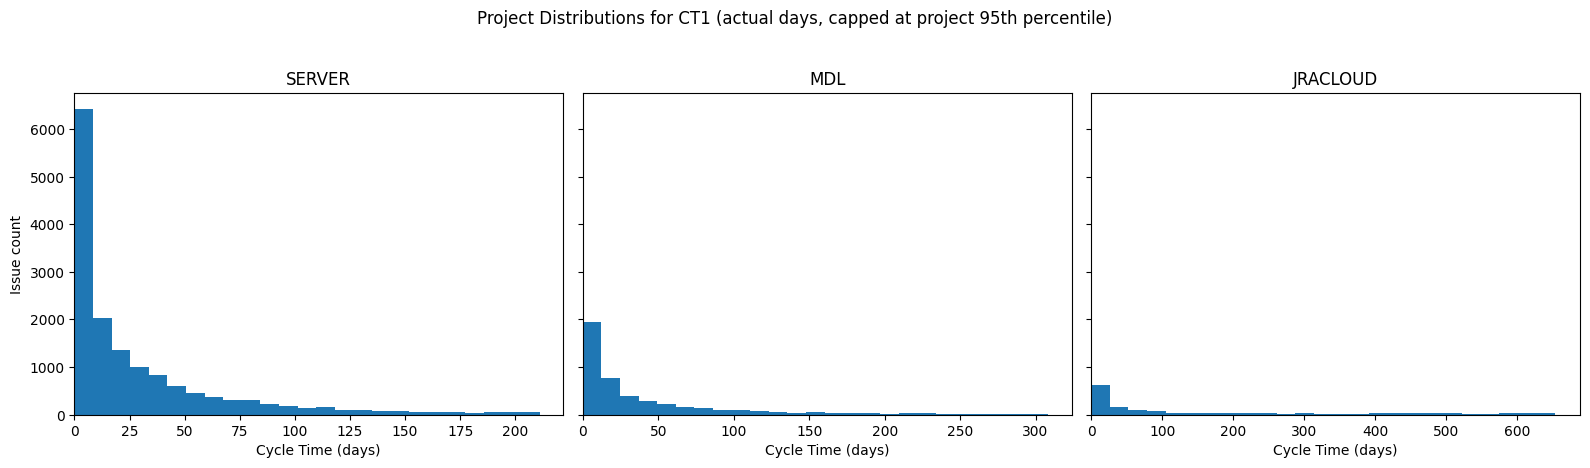

In [8]:
fig, axes = plt.subplots(1, len(project_order), figsize=(16, 4.5), sharey=True)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = main_df[main_df["Project_Key"] == project].copy()

    if proj_df.empty:
        ax.set_title(project)
        ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
        continue

    upper = np.percentile(proj_df["Cycle_Time_Days"], 95)
    clipped = proj_df[proj_df["Cycle_Time_Days"] <= upper]["Cycle_Time_Days"]

    ax.hist(clipped, bins=25)
    ax.set_title(project)
    ax.set_xlabel("Cycle Time (days)")
    ax.set_xlim(0, upper * 1.05)

axes[0].set_ylabel("Issue count")
fig.suptitle(f"Project Distributions for {MAIN_CT} (actual days, capped at project 95th percentile)", y=1.03)
fig.tight_layout()

save_figure(fig, f"histograms_{MAIN_CT.lower()}_by_project")
plt.show()

Cell 9 — Project boxplots for one CT definition

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplot_ct1_project_compare.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplot_ct1_project_compare.svg


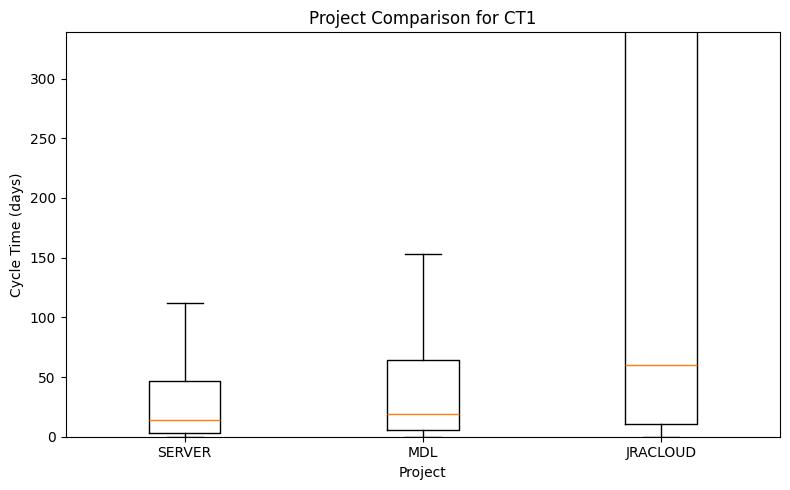

In [9]:
series = []
labels = []

for project in project_order:
    values = main_df.loc[main_df["Project_Key"] == project, "Cycle_Time_Days"].dropna().values
    if len(values) > 0:
        series.append(values)
        labels.append(project)

fig, ax = plt.subplots(figsize=(8, 5))

if series:
    ax.boxplot(series, tick_labels=labels, showfliers=False)

    global_upper = np.percentile(main_df["Cycle_Time_Days"], 95)
    ax.set_ylim(0, global_upper * 1.05)

ax.set_title(f"Project Comparison for {MAIN_CT}")
ax.set_xlabel("Project")
ax.set_ylabel("Cycle Time (days)")
fig.tight_layout()

save_figure(fig, f"boxplot_{MAIN_CT.lower()}_project_compare")
plt.show()

Cell 10 — Project ECDFs for one CT definition

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/ecdf_ct1_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/ecdf_ct1_by_project.svg


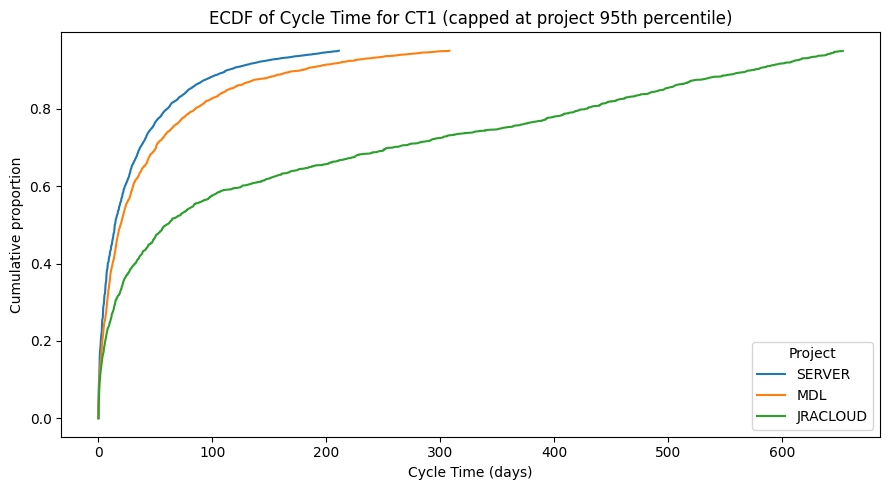

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for project in project_order:
    proj_df = main_df[main_df["Project_Key"] == project].copy()

    if proj_df.empty:
        continue

    x = np.sort(proj_df["Cycle_Time_Days"].values)
    y = np.arange(1, len(x) + 1) / len(x)

    upper = np.percentile(x, 95)
    mask = x <= upper

    ax.plot(x[mask], y[mask], label=project)

ax.set_title(f"ECDF of Cycle Time for {MAIN_CT} (capped at project 95th percentile)")
ax.set_xlabel("Cycle Time (days)")
ax.set_ylabel("Cumulative proportion")
ax.legend(title="Project")
fig.tight_layout()

save_figure(fig, f"ecdf_{MAIN_CT.lower()}_by_project")
plt.show()

Cell 11 — Repeat histograms for every CT definition, saved separately

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_ct1_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_ct1_by_project.svg


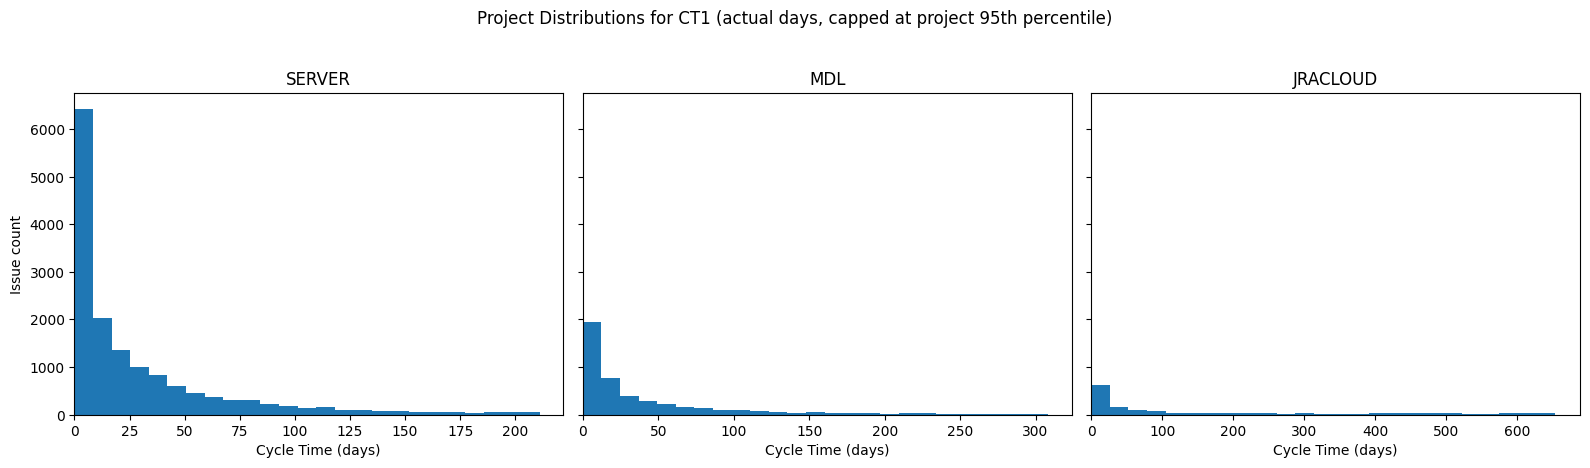

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_ct2_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_ct2_by_project.svg


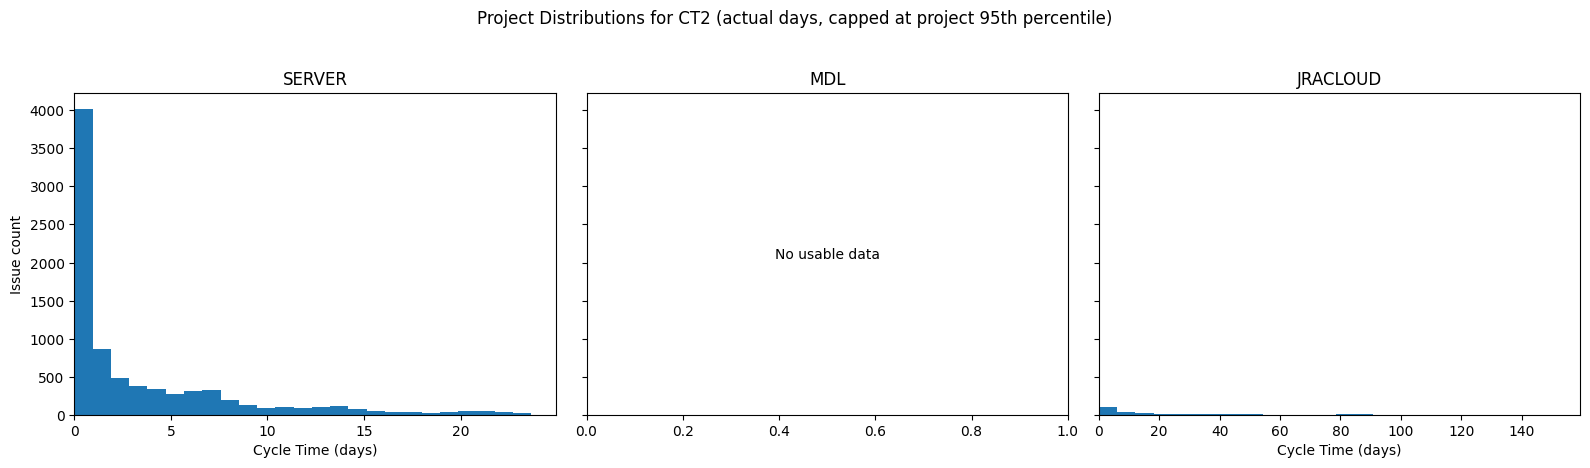

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_ct3_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_ct3_by_project.svg


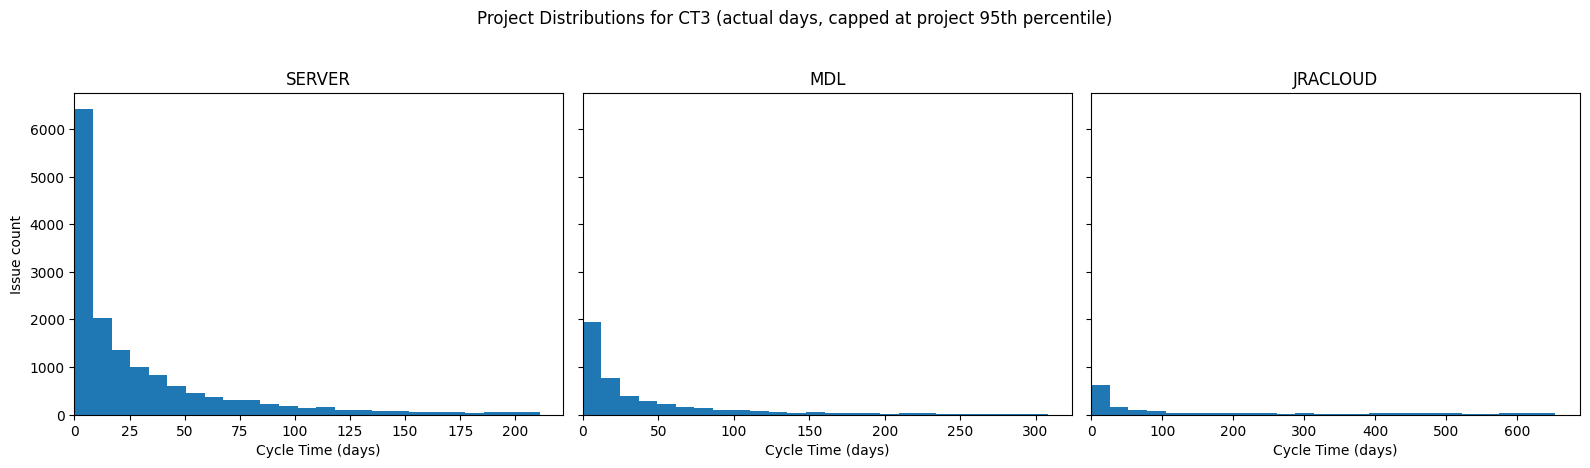

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_ct4_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_ct4_by_project.svg


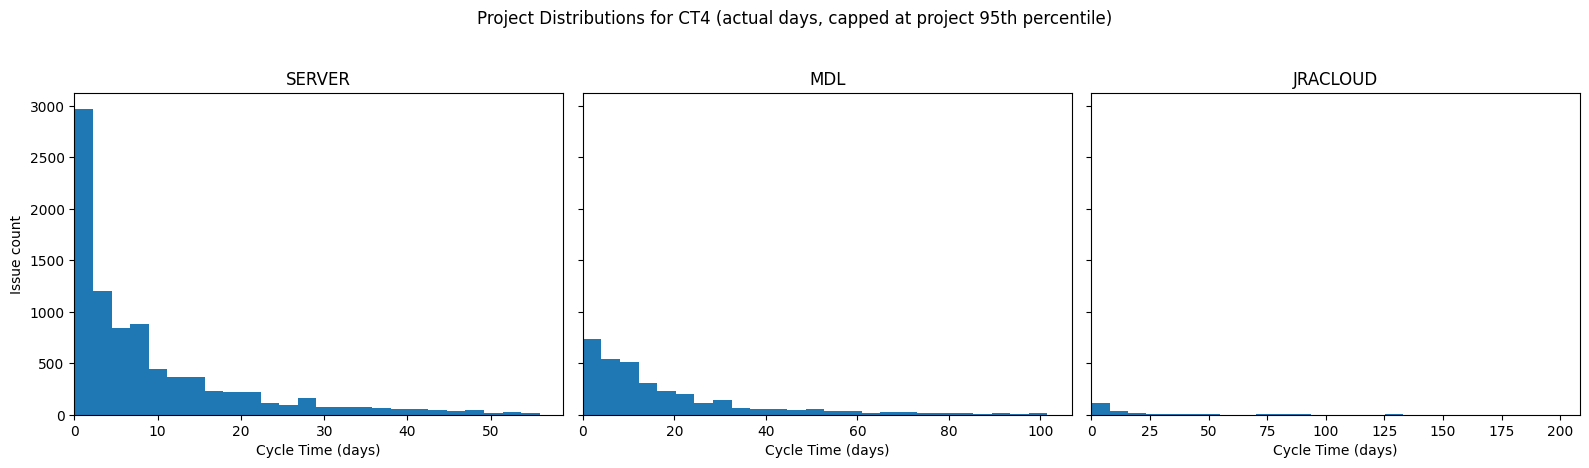

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_ct5_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_ct5_by_project.svg


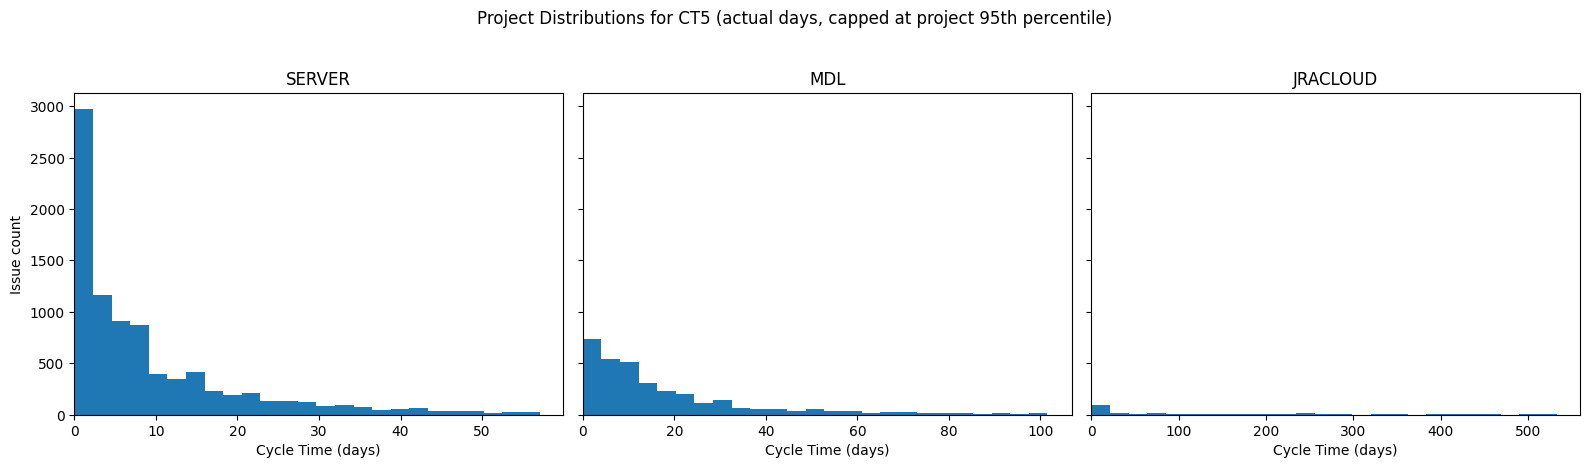

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_ct6_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_ct6_by_project.svg


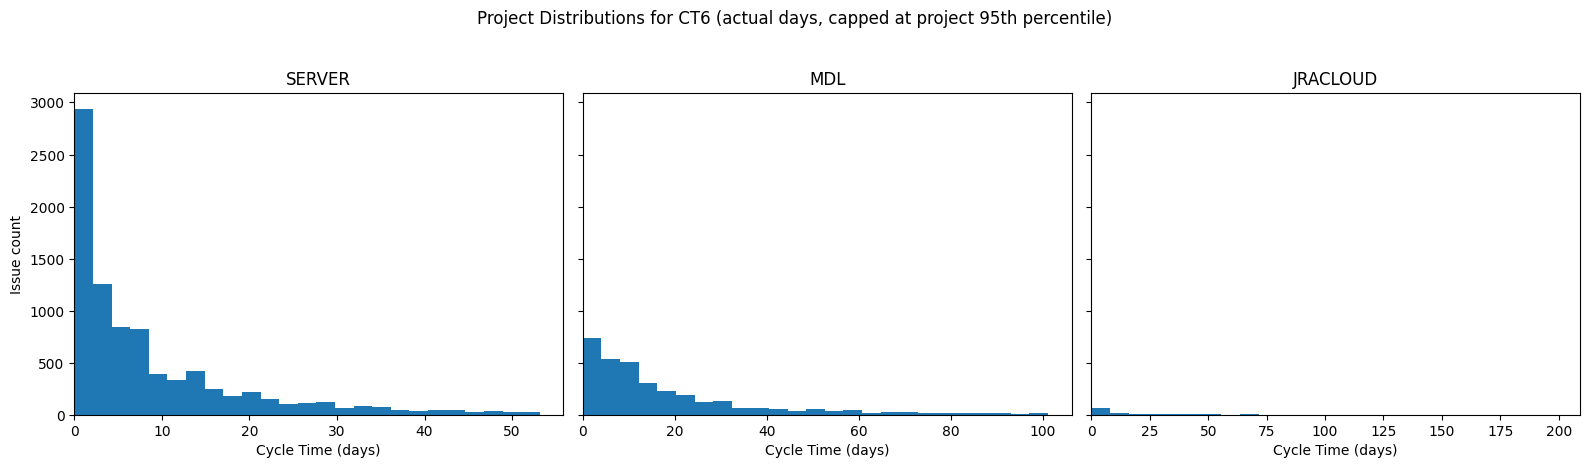

In [11]:
for ct in ct_order:
    ct_df = df[df["CT_Definition"] == ct].copy()

    fig, axes = plt.subplots(1, len(project_order), figsize=(16, 4.5), sharey=True)

    if len(project_order) == 1:
        axes = [axes]

    for ax, project in zip(axes, project_order):
        proj_df = ct_df[ct_df["Project_Key"] == project].copy()

        if proj_df.empty:
            ax.set_title(project)
            ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
            continue

        upper = np.percentile(proj_df["Cycle_Time_Days"], 95)
        clipped = proj_df[proj_df["Cycle_Time_Days"] <= upper]["Cycle_Time_Days"]

        ax.hist(clipped, bins=25)
        ax.set_title(project)
        ax.set_xlabel("Cycle Time (days)")
        ax.set_xlim(0, upper * 1.05)

    axes[0].set_ylabel("Issue count")
    fig.suptitle(f"Project Distributions for {ct} (actual days, capped at project 95th percentile)", y=1.03)
    fig.tight_layout()

    save_figure(fig, f"histograms_{ct.lower()}_by_project")
    plt.show()

Cell 12 — Repeat boxplots for every CT definition, saved separately

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplot_ct1_project_compare.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplot_ct1_project_compare.svg


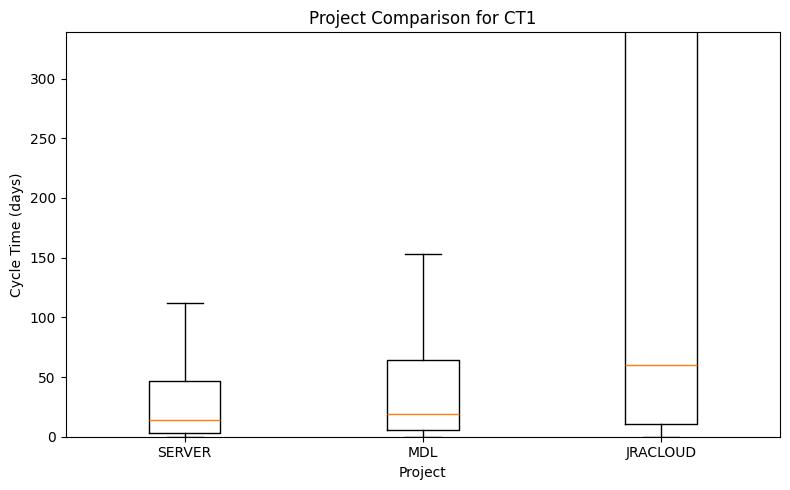

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplot_ct2_project_compare.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplot_ct2_project_compare.svg


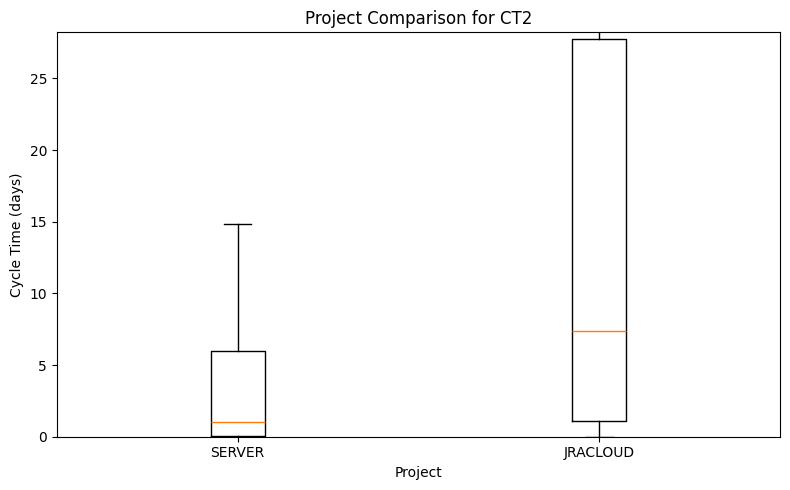

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplot_ct3_project_compare.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplot_ct3_project_compare.svg


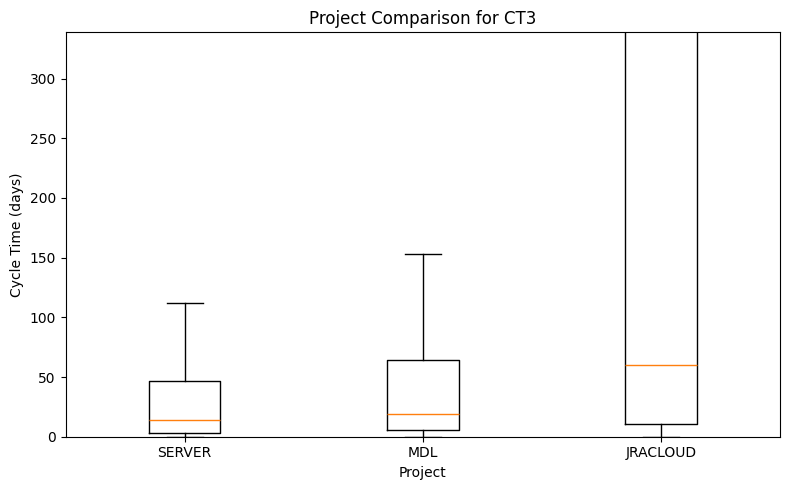

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplot_ct4_project_compare.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplot_ct4_project_compare.svg


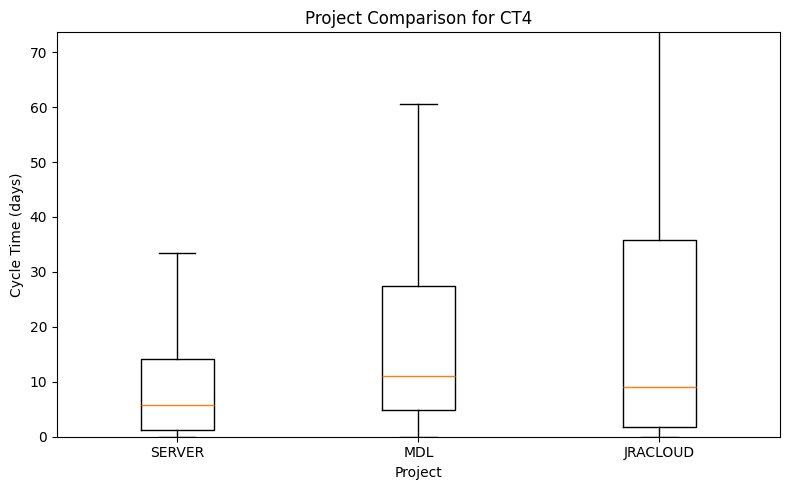

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplot_ct5_project_compare.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplot_ct5_project_compare.svg


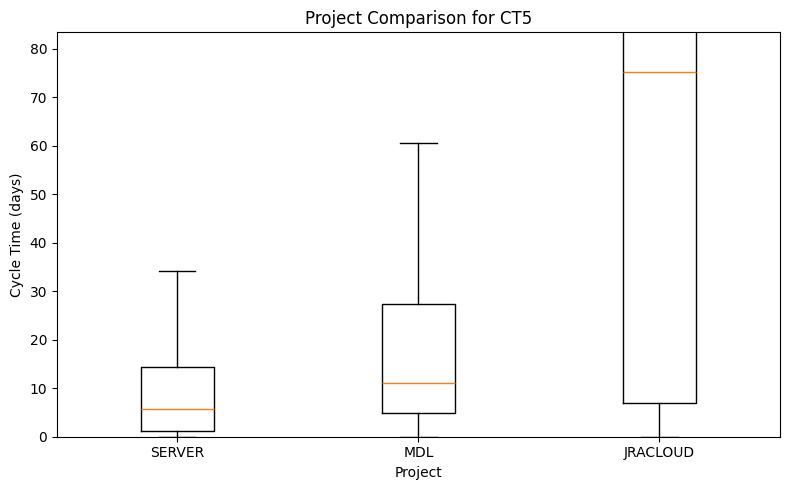

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplot_ct6_project_compare.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplot_ct6_project_compare.svg


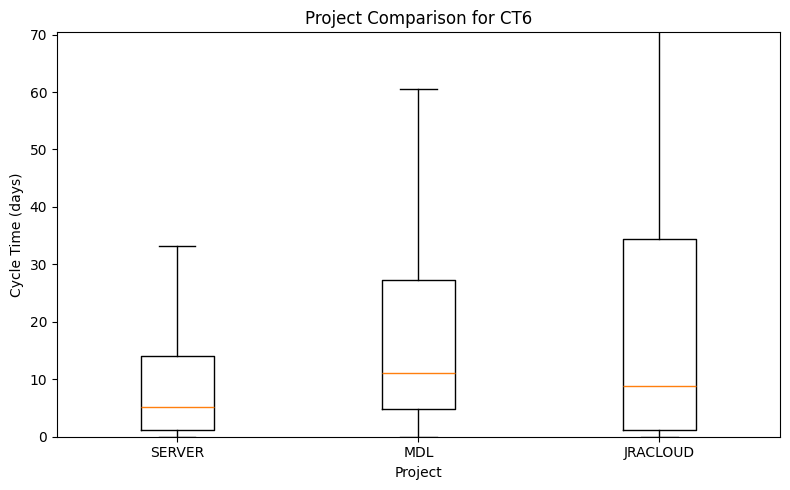

In [12]:
for ct in ct_order:
    ct_df = df[df["CT_Definition"] == ct].copy()

    series = []
    labels = []

    for project in project_order:
        values = ct_df.loc[ct_df["Project_Key"] == project, "Cycle_Time_Days"].dropna().values
        if len(values) > 0:
            series.append(values)
            labels.append(project)

    fig, ax = plt.subplots(figsize=(8, 5))

    if series:
        ax.boxplot(series, tick_labels=labels, showfliers=False)

        upper = np.percentile(ct_df["Cycle_Time_Days"], 95)
        ax.set_ylim(0, upper * 1.05)

    ax.set_title(f"Project Comparison for {ct}")
    ax.set_xlabel("Project")
    ax.set_ylabel("Cycle Time (days)")
    fig.tight_layout()

    save_figure(fig, f"boxplot_{ct.lower()}_project_compare")
    plt.show()

Cell 13 — Repeat ECDFs for every CT definition, saved separately

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/ecdf_ct1_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/ecdf_ct1_by_project.svg


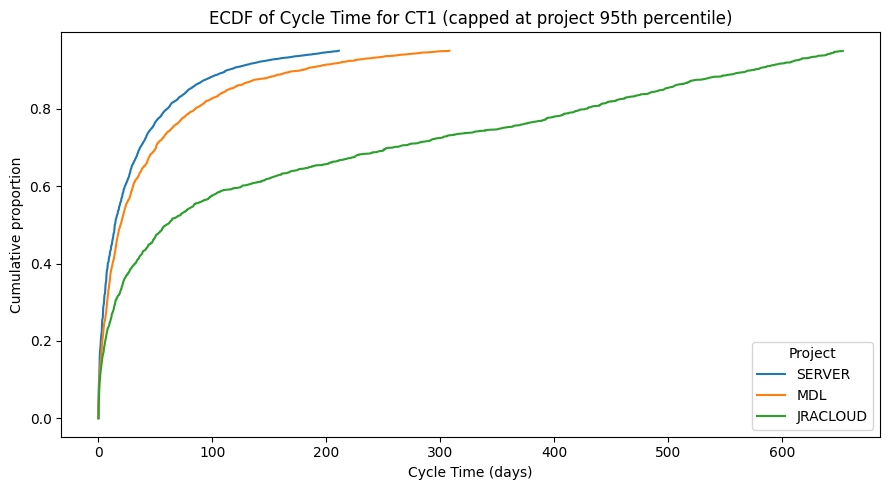

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/ecdf_ct2_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/ecdf_ct2_by_project.svg


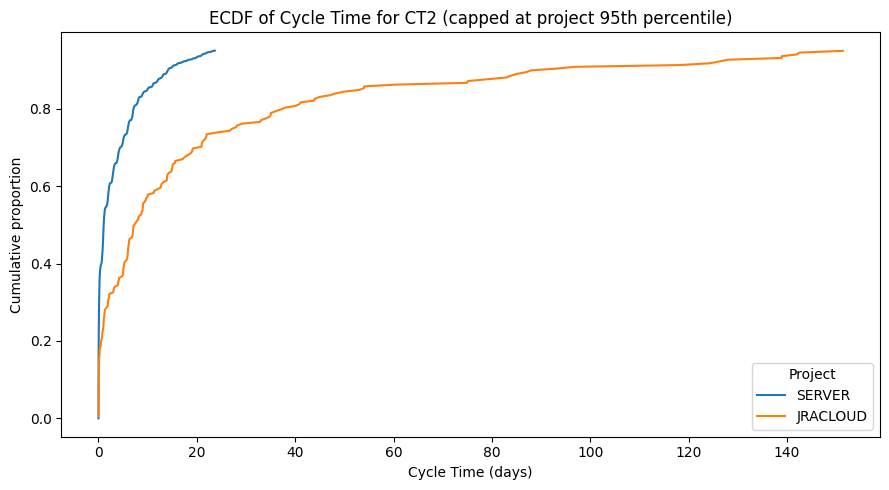

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/ecdf_ct3_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/ecdf_ct3_by_project.svg


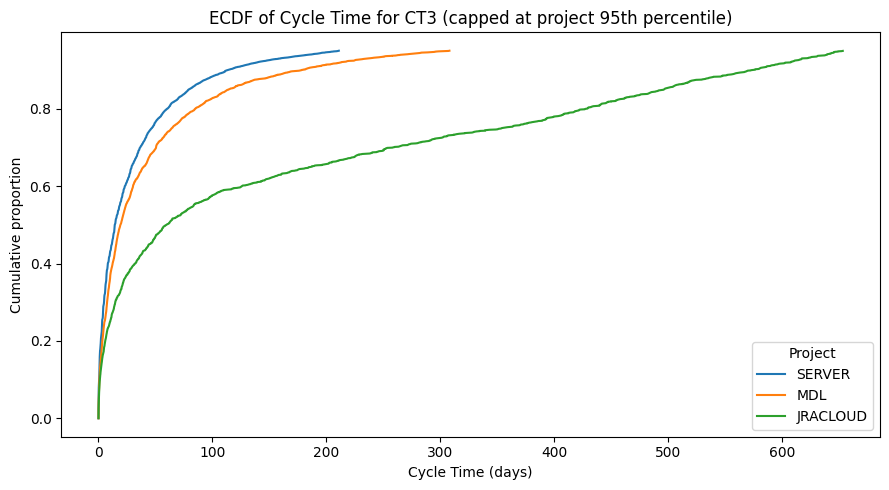

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/ecdf_ct4_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/ecdf_ct4_by_project.svg


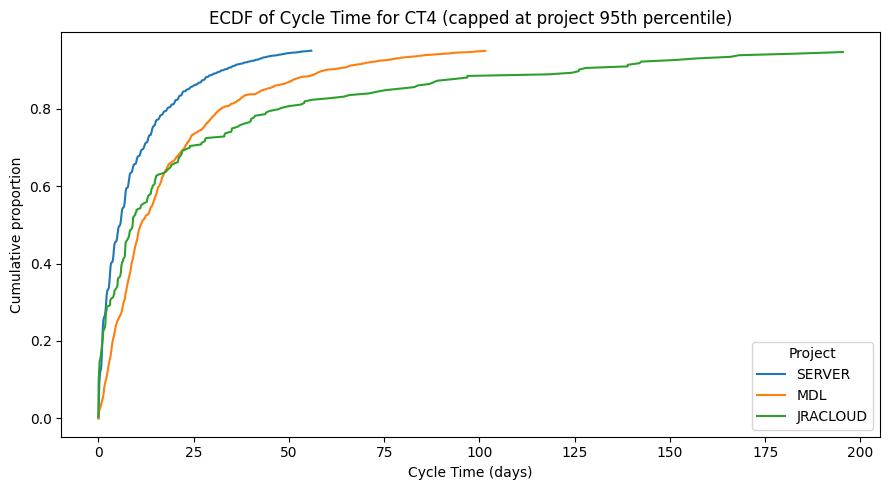

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/ecdf_ct5_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/ecdf_ct5_by_project.svg


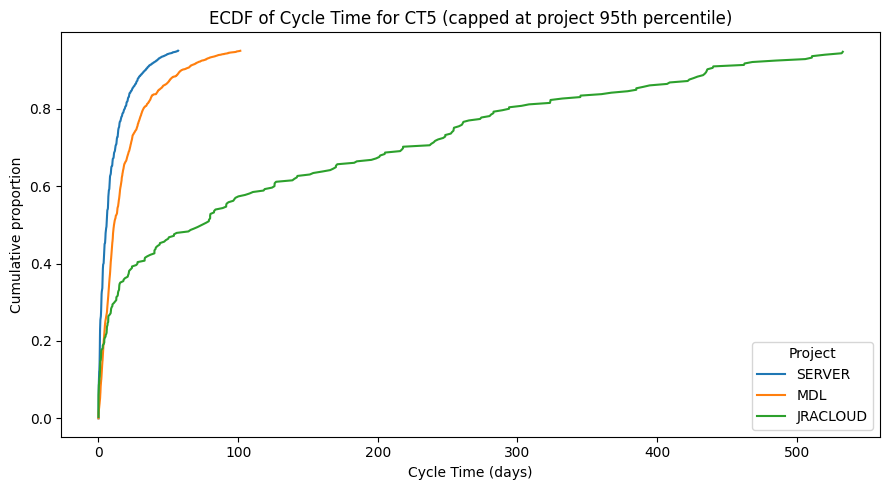

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/ecdf_ct6_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/ecdf_ct6_by_project.svg


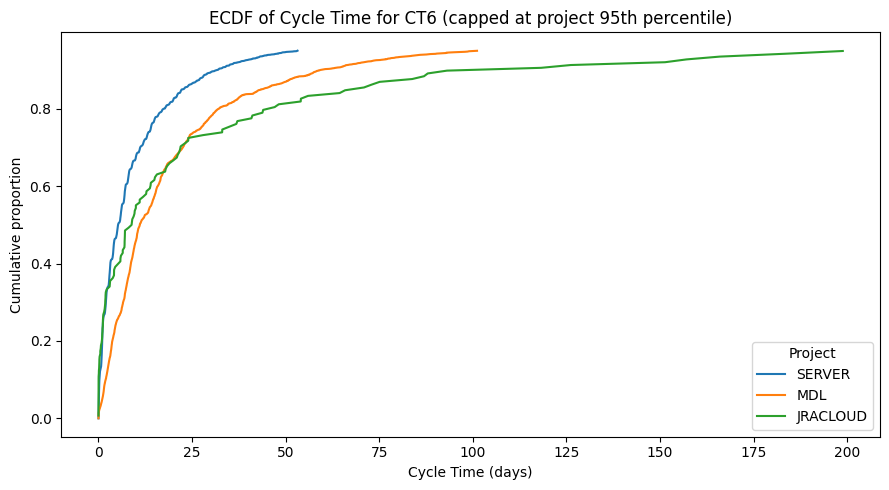

In [13]:
for ct in ct_order:
    ct_df = df[df["CT_Definition"] == ct].copy()

    fig, ax = plt.subplots(figsize=(9, 5))

    for project in project_order:
        proj_df = ct_df[ct_df["Project_Key"] == project].copy()

        if proj_df.empty:
            continue

        x = np.sort(proj_df["Cycle_Time_Days"].values)
        y = np.arange(1, len(x) + 1) / len(x)

        upper = np.percentile(x, 95)
        mask = x <= upper

        ax.plot(x[mask], y[mask], label=project)

    ax.set_title(f"ECDF of Cycle Time for {ct} (capped at project 95th percentile)")
    ax.set_xlabel("Cycle Time (days)")
    ax.set_ylabel("Cumulative proportion")
    ax.legend(title="Project")
    fig.tight_layout()

    save_figure(fig, f"ecdf_{ct.lower()}_by_project")
    plt.show()

Cell 14 — All usable observations pooled within each project

This one uses all usable observations across CT definitions. That means the same issue can appear multiple times if it is usable under multiple CT definitions. That is okay as long as you interpret it as a distribution of usable observations, not a unique-issue distribution.

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/histograms_all_usable_observations_by_project.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/histograms_all_usable_observations_by_project.svg


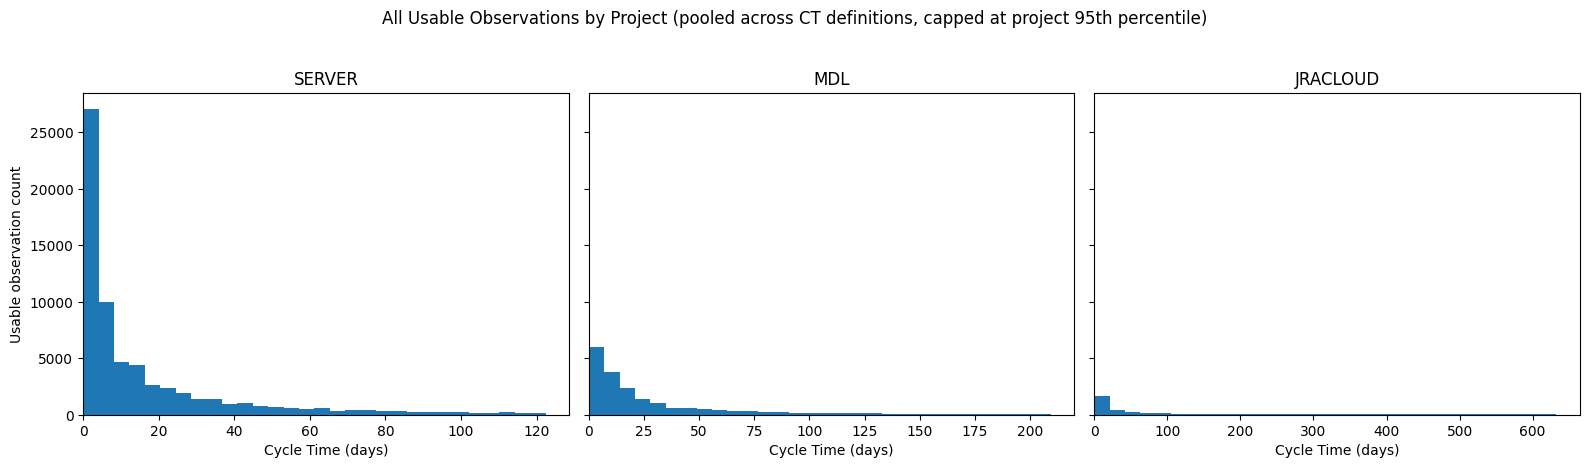

In [14]:
fig, axes = plt.subplots(1, len(project_order), figsize=(16, 4.5), sharey=True)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = df[df["Project_Key"] == project].copy()

    if proj_df.empty:
        ax.set_title(project)
        ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
        continue

    upper = np.percentile(proj_df["Cycle_Time_Days"], 95)
    clipped = proj_df[proj_df["Cycle_Time_Days"] <= upper]["Cycle_Time_Days"]

    ax.hist(clipped, bins=30)
    ax.set_title(project)
    ax.set_xlabel("Cycle Time (days)")
    ax.set_xlim(0, upper * 1.05)

axes[0].set_ylabel("Usable observation count")
fig.suptitle("All Usable Observations by Project (pooled across CT definitions, capped at project 95th percentile)", y=1.03)
fig.tight_layout()

save_figure(fig, "histograms_all_usable_observations_by_project")
plt.show()

# Cell 15 — Distribution by CT within each project

This is a useful complement: instead of project comparison for one CT, it compares CT definitions within each project.

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/png/boxplots_ct_within_project_actual_days.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/project_distributions/svg/boxplots_ct_within_project_actual_days.svg


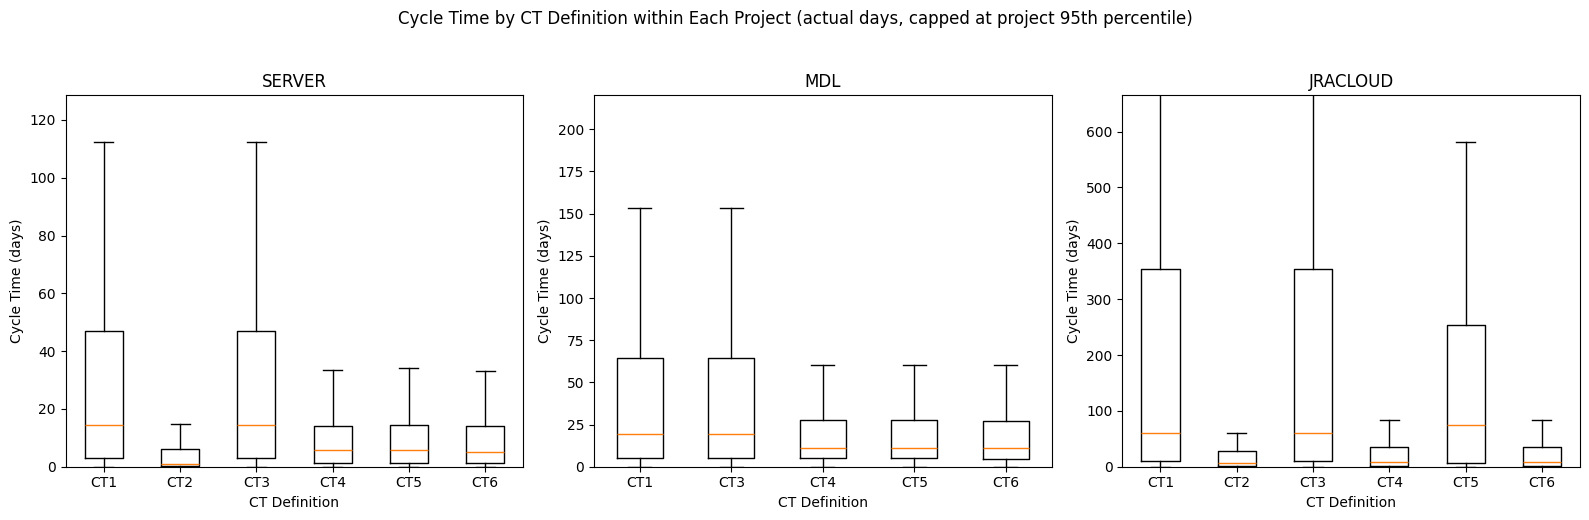

In [15]:
fig, axes = plt.subplots(1, len(project_order), figsize=(16, 5), sharey=False)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = df[df["Project_Key"] == project].copy()

    available_cts = [ct for ct in ct_order if ct in set(proj_df["CT_Definition"].astype(str))]

    series = []
    labels = []

    for ct in available_cts:
        values = proj_df.loc[
            proj_df["CT_Definition"].astype(str) == ct,
            "Cycle_Time_Days"
        ].dropna().values

        if len(values) > 0:
            series.append(values)
            labels.append(ct)

    if not series:
        ax.set_title(project)
        ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
        continue

    ax.boxplot(series, tick_labels=labels, showfliers=False)

    upper = np.percentile(proj_df["Cycle_Time_Days"], 95)
    ax.set_ylim(0, upper * 1.05)

    ax.set_title(project)
    ax.set_xlabel("CT Definition")
    ax.set_ylabel("Cycle Time (days)")

fig.suptitle("Cycle Time by CT Definition within Each Project (actual days, capped at project 95th percentile)", y=1.03)
fig.tight_layout()

save_figure(fig, "boxplots_ct_within_project_actual_days")
plt.show()

Cell 16 — File listing

In [16]:
print("PNG files:")
for p in sorted(PNG_DIR.glob("*.png")):
    print("-", p.name)

print("\nSVG files:")
for p in sorted(SVG_DIR.glob("*.svg")):
    print("-", p.name)

PNG files:
- boxplot_ct1_project_compare.png
- boxplot_ct2_project_compare.png
- boxplot_ct3_project_compare.png
- boxplot_ct4_project_compare.png
- boxplot_ct5_project_compare.png
- boxplot_ct6_project_compare.png
- boxplots_ct_within_project_actual_days.png
- ecdf_ct1_by_project.png
- ecdf_ct2_by_project.png
- ecdf_ct3_by_project.png
- ecdf_ct4_by_project.png
- ecdf_ct5_by_project.png
- ecdf_ct6_by_project.png
- histograms_all_usable_observations_by_project.png
- histograms_ct1_by_project.png
- histograms_ct2_by_project.png
- histograms_ct3_by_project.png
- histograms_ct4_by_project.png
- histograms_ct5_by_project.png
- histograms_ct6_by_project.png

SVG files:
- boxplot_ct1_project_compare.svg
- boxplot_ct2_project_compare.svg
- boxplot_ct3_project_compare.svg
- boxplot_ct4_project_compare.svg
- boxplot_ct5_project_compare.svg
- boxplot_ct6_project_compare.svg
- boxplots_ct_within_project_actual_days.svg
- ecdf_ct1_by_project.svg
- ecdf_ct2_by_project.svg
- ecdf_ct3_by_project.svg
-